# Task 4 — Train Baseline Model

## Objective

The objective of this task is to train a baseline classification model that predicts whether a customer will purchase a particular product in a future order.

The training and testing datasets are taken from the prepared outputs of Task 3.

### Target Definition

- `target = 1`: the customer-product pair appears in a future training order.
- `target = 0`: the customer-product pair does not appear in a future training order.

### Modeling Approach

A Logistic Regression classifier is used as the baseline model.

The preprocessing workflow includes:

- Loading the prepared training and testing datasets.
- Removing identifier columns that should not be used as predictive features.
- Treating department and aisle identifiers as categorical features.
- Scaling numerical features.
- One-hot encoding categorical features.
- Training Logistic Regression on the balanced training dataset.
- Evaluating the model on the untouched test dataset.

### Evaluation Metrics

The baseline model will be evaluated using:

- Accuracy
- F1-score
- Precision and Recall
- Classification Report
- Confusion Matrix

In [1]:
# ============================================================
# Task 4 — Imports
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Task 4 — Project Configuration
# ============================================================

PROJECT_ROOT = Path.cwd().parent

TRAIN_FILE = PROJECT_ROOT / "output" / "training_data" / "train.csv.gz"
TEST_FILE = PROJECT_ROOT / "output" / "training_data" / "test.csv.gz"

RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT)
print("Training file:", TRAIN_FILE)
print("Testing file:", TEST_FILE)

print("\nTraining file exists:", TRAIN_FILE.exists())
print("Testing file exists:", TEST_FILE.exists())

Project root: d:\PROJECTS\customer_demand_analysis
Training file: d:\PROJECTS\customer_demand_analysis\output\training_data\train.csv.gz
Testing file: d:\PROJECTS\customer_demand_analysis\output\training_data\test.csv.gz

Training file exists: True
Testing file exists: True


In [3]:
# ============================================================
# Task 4 — Load Prepared Training and Testing Data
# ============================================================

print("Loading training data...")
train_df = pd.read_csv(TRAIN_FILE)

print("Loading testing data...")
test_df = pd.read_csv(TEST_FILE)

print("\nData loading completed.")

print("\nTraining shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Loading training data...
Loading testing data...

Data loading completed.

Training shape: (1326118, 22)
Testing shape: (2661591, 22)


In [4]:
# ============================================================
# Task 4 — Initial Data Inspection
# ============================================================

print("Training data preview:")
display(train_df.head())

print("\nTraining data information:")
print(train_df.info())

print("\nTraining data descriptive statistics:")
display(train_df.describe())

Training data preview:


,user_id,product_id,user_product_purchase_count,user_product_reorder_count,user_product_last_order_number,user_product_reorder_rate,user_product_avg_cart_position,user_product_recency_orders,department_id,user_department_purchase_count,...,user_aisle_purchase_count,user_aisle_purchase_share,user_total_orders,user_avg_days_between_orders,user_avg_order_hour,user_avg_order_dow,product_total_purchases,product_unique_users,product_reorder_rate,target
0,62738,7559,4,3,27,0.750000,15.500000,2,13,15,...,4,0.007030,29,12.535714,15.655172,2.413793,12102,4919,0.593538,1
1,133114,43713,12,11,45,0.916667,12.916667,0,13,27,...,14,0.015021,45,6.568182,14.266667,3.666667,18040,7795,0.567905,1
2,98330,43194,1,0,7,0.000000,6.000000,1,17,6,...,2,0.021978,8,5.000000,16.875000,4.125000,1562,792,0.492958,0
3,157908,13573,1,0,14,0.000000,9.000000,2,3,5,...,1,0.007634,16,13.933333,15.875000,1.812500,507,151,0.702170,0
4,32078,1337,2,1,2,0.500000,2.000000,1,16,11,...,4,0.095238,3,30.000000,17.333333,1.000000,976,231,0.763320,1



Training data information:
<class 'pandas.DataFrame'>
RangeIndex: 1326118 entries, 0 to 1326117
Data columns (total 22 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1326118 non-null  int64  
 1   product_id                      1326118 non-null  int64  
 2   user_product_purchase_count     1326118 non-null  int64  
 3   user_product_reorder_count      1326118 non-null  int64  
 4   user_product_last_order_number  1326118 non-null  int64  
 5   user_product_reorder_rate       1326118 non-null  float64
 6   user_product_avg_cart_position  1326118 non-null  float64
 7   user_product_recency_orders     1326118 non-null  int64  
 8   department_id                   1326118 non-null  int64  
 9   user_department_purchase_count  1326118 non-null  int64  
 10  user_department_purchase_share  1326118 non-null  float64
 11  aisle_id                        1326118 non-nu

,user_id,product_id,user_product_purchase_count,user_product_reorder_count,user_product_last_order_number,user_product_reorder_rate,user_product_avg_cart_position,user_product_recency_orders,department_id,user_department_purchase_count,...,user_aisle_purchase_count,user_aisle_purchase_share,user_total_orders,user_avg_days_between_orders,user_avg_order_hour,user_avg_order_dow,product_total_purchases,product_unique_users,product_reorder_rate,target
count,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,...,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1.326118e+06,1326118.0
mean,1.029327e+05,2.556791e+04,3.688072e+00,2.688072e+00,1.631248e+01,3.847312e-01,8.791656e+00,6.166982e+00,9.920080e+00,5.103640e+01,...,1.826638e+01,7.877738e-02,2.247947e+01,1.333469e+01,1.357707e+01,2.726868e+00,3.263458e+04,8.655858e+03,5.730170e-01,0.5
std,5.946944e+04,1.413560e+04,5.458729e+00,5.458729e+00,1.739177e+01,3.712957e-01,6.640089e+00,1.100068e+01,6.266506e+00,7.850362e+01,...,3.391157e+01,9.067808e-02,2.077409e+01,6.624224e+00,1.939253e+00,8.745877e-01,7.497711e+04,1.458764e+04,1.550945e-01,0.5
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,2.684564e-04,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.0
25%,5.147100e+04,1.342400e+04,1.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,4.000000e+00,9.000000e+00,...,3.000000e+00,1.935484e-02,7.000000e+00,8.000000e+00,1.233333e+01,2.222222e+00,1.409000e+03,6.490000e+02,4.873035e-01,0.0
50%,1.026870e+05,2.540700e+04,2.000000e+00,1.000000e+00,1.000000e+01,5.000000e-01,7.000000e+00,2.000000e+00,9.000000e+00,2.300000e+01,...,7.000000e+00,4.657180e-02,1.500000e+01,1.223077e+01,1.356098e+01,2.750000e+00,5.943000e+03,2.428000e+03,5.967574e-01,0.5
75%,1.545490e+05,3.802800e+04,4.000000e+00,3.000000e+00,2.200000e+01,7.500000e-01,1.175000e+01,7.000000e+00,1.600000e+01,5.800000e+01,...,1.900000e+01,1.071429e-01,3.100000e+01,1.776471e+01,1.480000e+01,3.236364e+00,2.495000e+04,9.115000e+03,6.836615e-01,1.0
max,2.062090e+05,4.968800e+04,9.900000e+01,9.800000e+01,9.900000e+01,9.898990e-01,1.200000e+02,9.800000e+01,2.100000e+01,1.559000e+03,...,1.522000e+03,1.000000e+00,9.900000e+01,3.000000e+01,2.300000e+01,6.000000e+00,4.725650e+05,7.395600e+04,9.411765e-01,1.0


In [5]:
# ============================================================
# Task 4 — Target Distribution
# ============================================================

print("Training target distribution:")
print(train_df["target"].value_counts().sort_index())

print("\nTraining target proportions:")
print(train_df["target"].value_counts(normalize=True).sort_index())

print("\nTesting target distribution:")
print(test_df["target"].value_counts().sort_index())

print("\nTesting target proportions:")
print(test_df["target"].value_counts(normalize=True).sort_index())

Training target distribution:
target
0    663059
1    663059
Name: count, dtype: int64

Training target proportions:
target
0    0.5
1    0.5
Name: proportion, dtype: float64

Testing target distribution:
target
0    2495826
1     165765
Name: count, dtype: int64

Testing target proportions:
target
0    0.93772
1    0.06228
Name: proportion, dtype: float64


## Feature Selection and Preprocessing

The `user_id` and `product_id` columns are identifiers and are excluded from model training.

The `department_id` and `aisle_id` columns represent categorical product information and are one-hot encoded rather than treated as continuous numerical values.

The remaining engineered behavioral and aggregate features are treated as numerical variables and standardized before Logistic Regression.

In [6]:
# ============================================================
# Task 4 — Feature Selection
# ============================================================

TARGET_COLUMN = "target"

ID_COLUMNS = [
    "user_id",
    "product_id"
]

CATEGORICAL_FEATURES = [
    "department_id",
    "aisle_id"
]

NUMERICAL_FEATURES = [
    "user_product_purchase_count",
    "user_product_reorder_count",
    "user_product_last_order_number",
    "user_product_reorder_rate",
    "user_product_avg_cart_position",
    "user_product_recency_orders",
    "user_department_purchase_count",
    "user_department_purchase_share",
    "user_aisle_purchase_count",
    "user_aisle_purchase_share",
    "user_total_orders",
    "user_avg_days_between_orders",
    "user_avg_order_hour",
    "user_avg_order_dow",
    "product_total_purchases",
    "product_unique_users",
    "product_reorder_rate"
]

FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

X_train = train_df[FEATURE_COLUMNS].copy()
y_train = train_df[TARGET_COLUMN].copy()

X_test = test_df[FEATURE_COLUMNS].copy()
y_test = test_df[TARGET_COLUMN].copy()

print("Number of selected features:", len(FEATURE_COLUMNS))

print("\nCategorical features:")
print(CATEGORICAL_FEATURES)

print("\nNumerical features:")
print(NUMERICAL_FEATURES)

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Number of selected features: 19

Categorical features:
['department_id', 'aisle_id']

Numerical features:
['user_product_purchase_count', 'user_product_reorder_count', 'user_product_last_order_number', 'user_product_reorder_rate', 'user_product_avg_cart_position', 'user_product_recency_orders', 'user_department_purchase_count', 'user_department_purchase_share', 'user_aisle_purchase_count', 'user_aisle_purchase_share', 'user_total_orders', 'user_avg_days_between_orders', 'user_avg_order_hour', 'user_avg_order_dow', 'product_total_purchases', 'product_unique_users', 'product_reorder_rate']

Training feature shape: (1326118, 19)
Testing feature shape: (2661591, 19)


In [7]:
# ============================================================
# Task 4 — Missing Value Check
# ============================================================

missing_train = X_train.isna().sum()
missing_test = X_test.isna().sum()

print("Missing values in training features:")
print(missing_train[missing_train > 0])

print("\nMissing values in testing features:")
print(missing_test[missing_test > 0])

print("\nTotal missing values in training:", missing_train.sum())
print("Total missing values in testing:", missing_test.sum())

Missing values in training features:
Series([], dtype: int64)

Missing values in testing features:
Series([], dtype: int64)

Total missing values in training: 0
Total missing values in testing: 0


## Preprocessing Pipeline

The preprocessing steps are implemented using a scikit-learn `ColumnTransformer` and `Pipeline`.

- Numerical features are standardized using `StandardScaler`.
- Categorical features are one-hot encoded using `OneHotEncoder`.
- Unknown categorical values in the test data are ignored.
- The preprocessing is fitted only on the training data and then applied to the test data.

This prevents information from the test set from influencing the preprocessing stage.

In [8]:
# ============================================================
# Task 4 — Build Preprocessing Pipeline
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            NUMERICAL_FEATURES
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            CATEGORICAL_FEATURES
        )
    ]
)

print("Preprocessing pipeline created successfully.")
print("\nNumerical transformation: StandardScaler")
print("Categorical transformation: OneHotEncoder")

Preprocessing pipeline created successfully.

Numerical transformation: StandardScaler
Categorical transformation: OneHotEncoder


## Baseline Model — Logistic Regression

Logistic Regression is used as the baseline classification model.

The model is trained using the balanced training dataset created in Task 3. The untouched test dataset is used for final evaluation.

The preprocessing and model are combined into a single pipeline so that the same transformations are consistently applied during training and prediction.

In [9]:
# ============================================================
# Task 4 — Logistic Regression Baseline
# ============================================================

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=100,
                random_state=RANDOM_STATE
            )
        )
    ]
)

print("Logistic Regression baseline pipeline created.")

Logistic Regression baseline pipeline created.


## Model Training

The Logistic Regression baseline is now fitted using the balanced training dataset.

Only the training data is used to learn the preprocessing transformations and model coefficients.

In [10]:
# ============================================================
# Task 4 — Train Logistic Regression
# ============================================================

print("Training Logistic Regression baseline...")
print("This may take some time because the training dataset contains",
      f"{len(X_train):,} rows.")

baseline_model.fit(X_train, y_train)

print("\nModel training completed successfully.")

Training Logistic Regression baseline...
This may take some time because the training dataset contains 1,326,118 rows.

Model training completed successfully.


## Model Prediction

The trained baseline model is used to generate predictions for the untouched test dataset.

The test set retains the original class distribution from Task 3 and is not resampled or rebalanced.

In [11]:
# ============================================================
# Task 4 — Generate Test Predictions
# ============================================================

print("Generating predictions on the test dataset...")

y_pred = baseline_model.predict(X_test)

print("Prediction completed successfully.")

print("\nNumber of predictions:", len(y_pred))
print("Actual test labels:", len(y_test))

Generating predictions on the test dataset...
Prediction completed successfully.

Number of predictions: 2661591
Actual test labels: 2661591


## Baseline Model Evaluation

The baseline model is evaluated using Accuracy and F1-score.

- **Accuracy** measures the overall proportion of correct predictions.
- **F1-score** balances precision and recall and is particularly important here because the untouched test set has an imbalanced target distribution.

In [12]:
# ============================================================
# Task 4 — Accuracy and F1-score
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Baseline Logistic Regression Results")
print("=" * 45)
print(f"Accuracy : {accuracy:.4f}")
print(f"F1-score : {f1:.4f}")

Baseline Logistic Regression Results
Accuracy : 0.7140
F1-score : 0.2454


In [13]:
# ============================================================
# Task 4 — Classification Report
# ============================================================

print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Future Purchase", "Future Purchase"]
    )
)

Classification Report
                    precision    recall  f1-score   support

No Future Purchase       0.98      0.71      0.82   2495826
   Future Purchase       0.15      0.75      0.25    165765

          accuracy                           0.71   2661591
         macro avg       0.56      0.73      0.53   2661591
      weighted avg       0.93      0.71      0.79   2661591



## Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each target class.

It provides a more detailed view of model performance than accuracy alone.

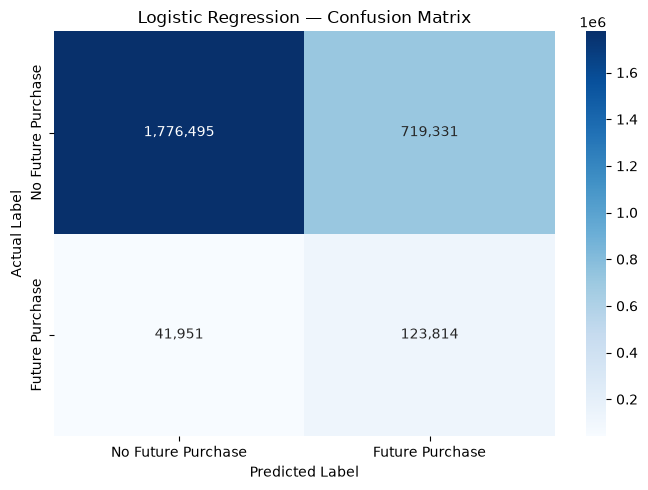

In [14]:
# ============================================================
# Task 4 — Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    xticklabels=["No Future Purchase", "Future Purchase"],
    yticklabels=["No Future Purchase", "Future Purchase"]
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

## Target Balance Visualization

The training dataset was balanced through random undersampling in Task 3, while the test dataset retains the original class distribution.

The following visualization compares the target distribution in the training and testing datasets.

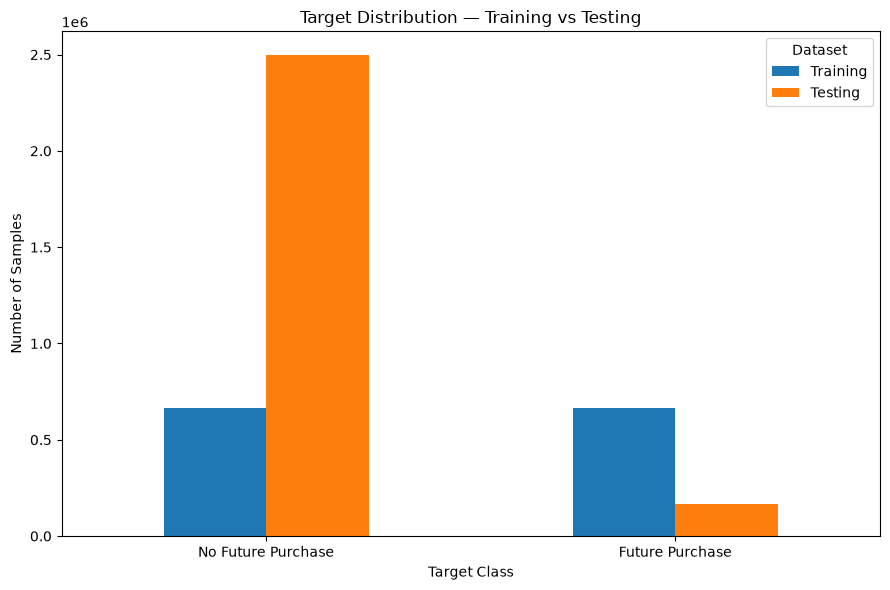

In [15]:
# ============================================================
# Task 4 — Target Balance Visualization
# ============================================================

train_target_counts = train_df["target"].value_counts().sort_index()
test_target_counts = test_df["target"].value_counts().sort_index()

target_distribution = pd.DataFrame({
    "Training": train_target_counts,
    "Testing": test_target_counts
})

target_distribution.index = [
    "No Future Purchase",
    "Future Purchase"
]

ax = target_distribution.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Target Distribution — Training vs Testing")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

## Feature Distribution Visualization

The following plots show the distributions of selected numerical features.

A random sample is used only for visualization because the full training dataset contains more than 1.3 million observations. The sampling does not affect model training or evaluation.

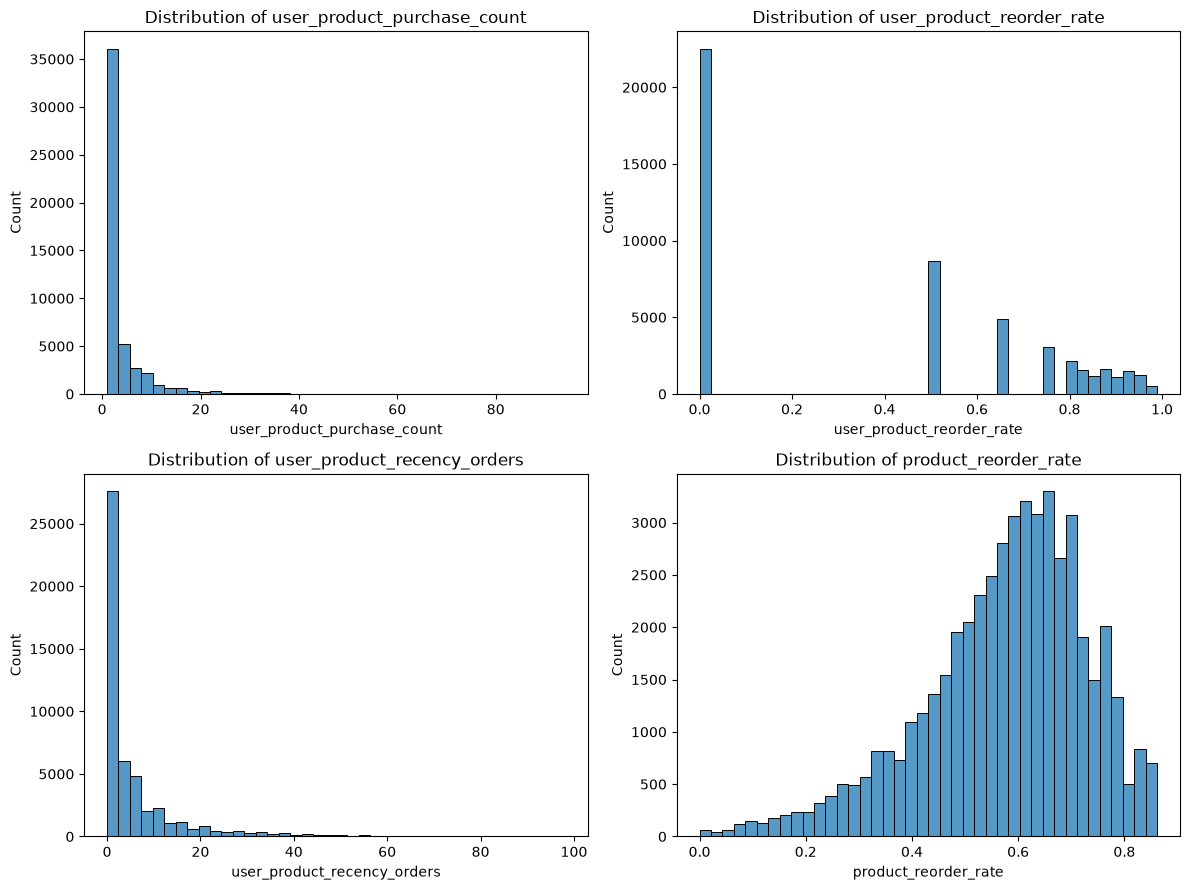

In [16]:
# ============================================================
# Task 4 — Feature Distribution Visualization
# ============================================================

plot_sample = train_df.sample(
    n=min(50000, len(train_df)),
    random_state=RANDOM_STATE
)

selected_plot_features = [
    "user_product_purchase_count",
    "user_product_reorder_rate",
    "user_product_recency_orders",
    "product_reorder_rate"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.flatten()

for ax, feature in zip(axes, selected_plot_features):
    sns.histplot(
        data=plot_sample,
        x=feature,
        bins=40,
        kde=False,
        ax=ax
    )
    
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Feature Distributions by Target Class

The following visualization compares selected behavioral features between customers who did and did not purchase the product in a future order.

These distributions provide an initial visual indication of whether the engineered features contain useful predictive information.

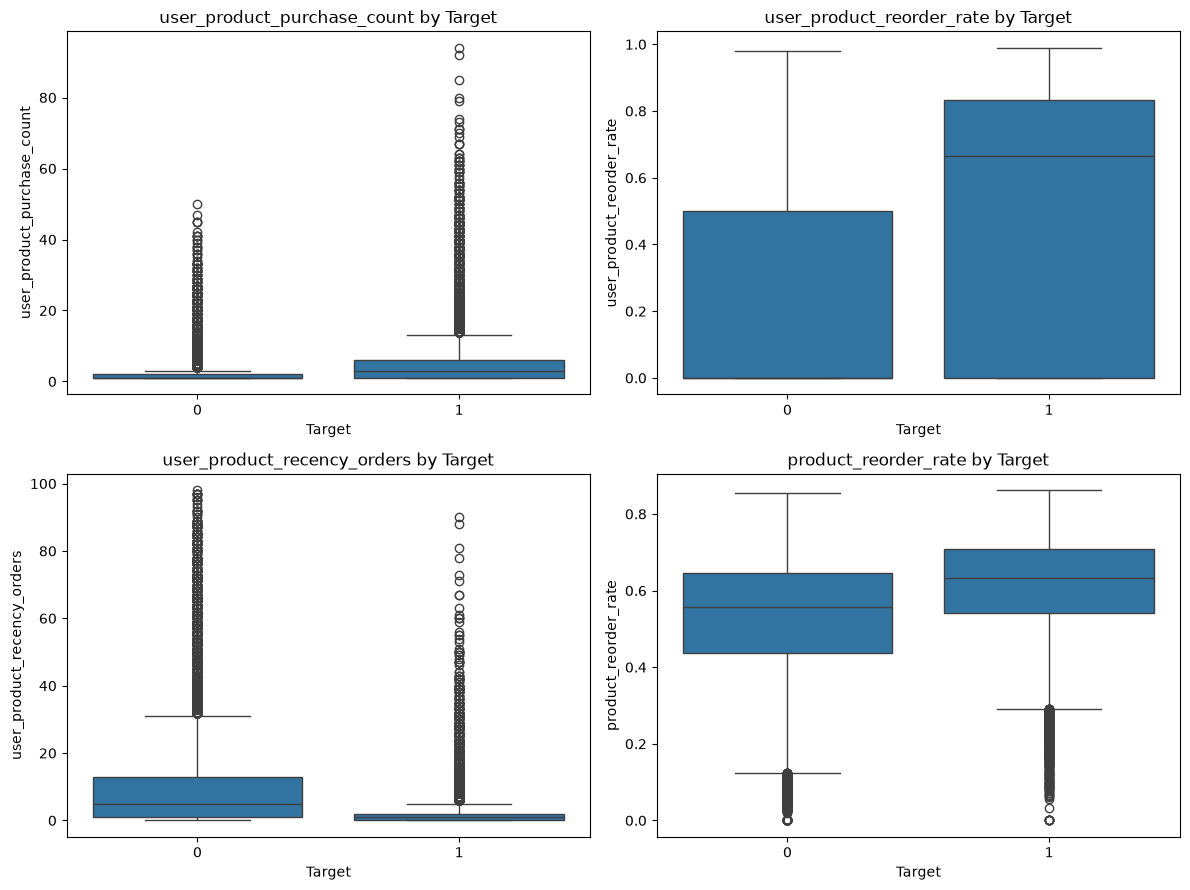

In [17]:
# ============================================================
# Task 4 — Feature Distributions by Target
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.flatten()

for ax, feature in zip(axes, selected_plot_features):
    sns.boxplot(
        data=plot_sample,
        x="target",
        y=feature,
        ax=ax
    )
    
    ax.set_title(f"{feature} by Target")
    ax.set_xlabel("Target")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## Baseline Model Results

The Logistic Regression baseline achieved:

- **Accuracy:** 0.7140
- **F1-score:** 0.2454

On the positive class (`target = 1`):

- **Precision:** 0.15
- **Recall:** 0.75
- **F1-score:** 0.25

The model identifies a substantial proportion of future purchases, as indicated by the 75% recall. However, the relatively low precision indicates that many predicted future purchases are false positives.

Because the test dataset retains the original class distribution, accuracy alone is not sufficient to evaluate the model. The positive-class F1-score and precision/recall provide a more informative view of baseline performance.

## Conclusion

A Logistic Regression model was successfully trained as the baseline classifier for future customer-product purchase prediction.

The Task 3 prepared training dataset was balanced using random undersampling, while the test dataset retained the original class distribution. The baseline model used standardized numerical features and one-hot encoded categorical features.

The model achieved an accuracy of **71.40%** and an F1-score of **0.2454** on the untouched test dataset.

The results show that the baseline model can identify many future purchases, with a recall of **75%** for the positive class. However, its precision of **15%** indicates a high number of false-positive predictions. Therefore, the baseline provides a useful starting point, but there is substantial scope for improving predictive precision and overall F1 performance through more advanced modeling and feature refinement.

This baseline establishes a reference point for future model improvements.